# Chapter-04. Autograd机制

## 【章节目标】
- 理解AutoGrad自动求导的原理
- 理解tensor求导机制
- 掌握使用autograd机制实现优化求解参数
- 了解优化器工作原理

## 【章节内容】
### 4.1 计算图

在深度学习框架中，反向传播的计算依赖于autograd自动微分机制(这里说的自动微分，即指求导/梯度)。而autograd实现的基础，有以下两个部分：

1.数学基础——链式求导法则  
2.底层结构基础——由Tensor张量和Function为基础构成的计算图模型(DAG有向无环图)。 在pytorch和tensorflow中，底层结构都是由tensor组成的计算图，虽然框架代码在实际autograd自动求梯度的过程中，并没有显示地构造和展示出计算图，不过其计算路径确实是沿着计算图的路径来进行的。所以，为了方便理解，我们需要了解计算图的概念。  
#### 1）链式求导  

例如：一个神经网络中有5个神经元a,b,c,d,L；其中w1、w2、w3、w4为权重矩阵，L为输出。满足以下计算关系：
- b = w1 * a
- c = w2 * a
- d = w3 * b + w4 * c
- L = 10 - d 组成的前向计算图如下：  
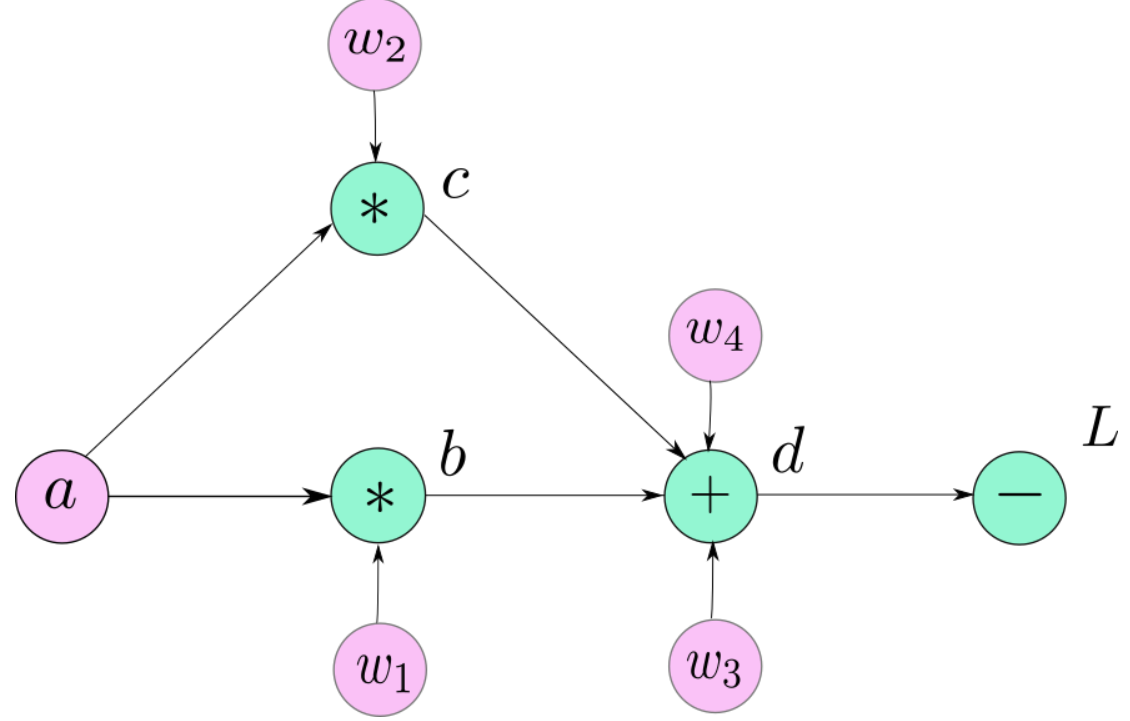
- L对w1的偏导 ：∂L / ∂w1 = (∂L / ∂d) * (∂d / ∂b) * (∂b / ∂w1)
- L对a的偏导：∂L / ∂a = ((∂L / ∂d) * (∂d / ∂b) * (∂b / ∂a)) + ((∂L / ∂d) * (∂d / ∂c) * (∂c / ∂a))  

反向传播计算过程就类似如下的计算图：  
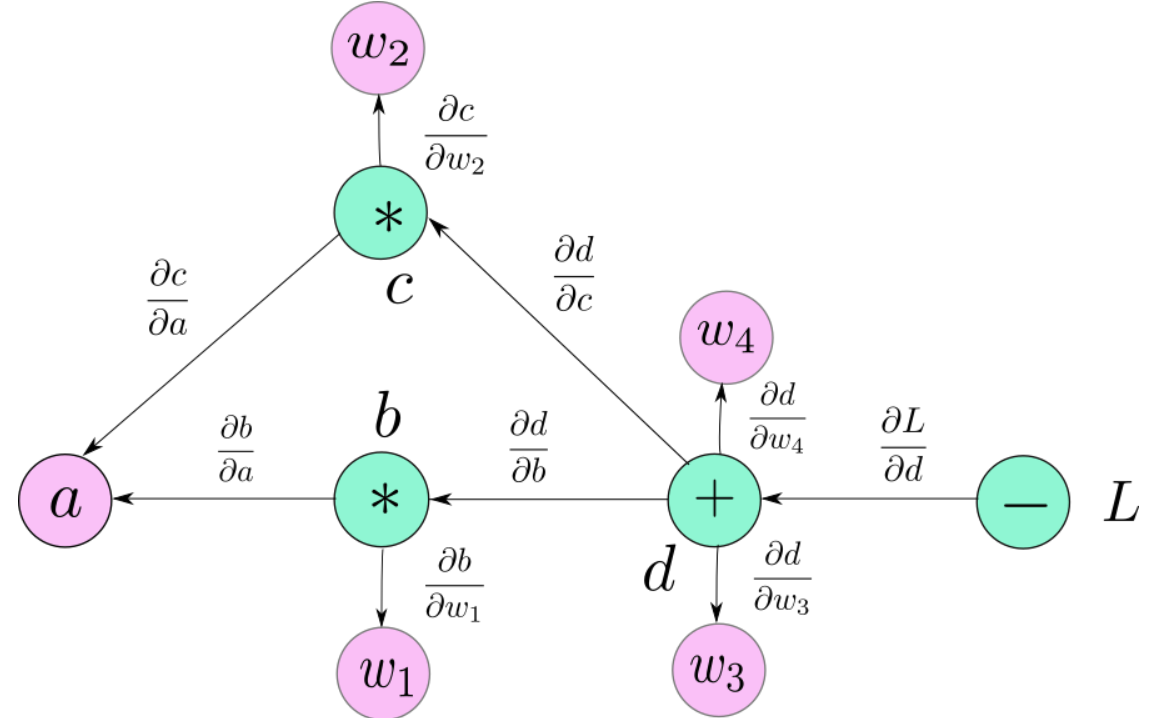  

Pytorch实际实现的计算图：  
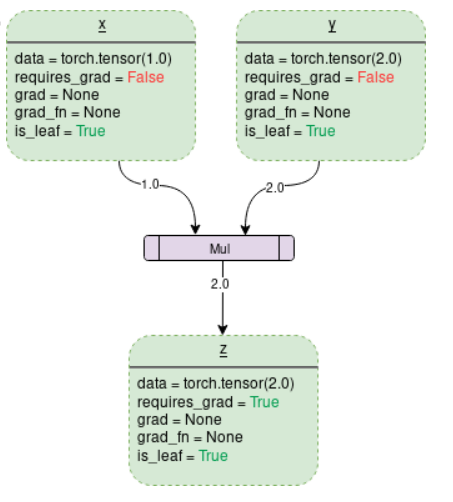  
该计算图表示了pytorch中的计算过程：x = 1.0 y = 2.0 z = x × y。其中，紫色节点为计算符；绿色节点为Tensor张量，框中存储的data,grad,is_leaf等为Tensor的部分属性；

#### 2）Tensor

Variable是对Tensor的封装，主要是为了进行自动求导，操作与tensor基本一致，不同的是，每一个Variable被构建的时候，都包含五个属性：
- data: 该张量节点存储的值；
- grad: 存储梯度的值，初始为None
- grad_fn : 反向传播时，用来计算梯度的函数；
- requires_ grad : 表示autograd时是否需要计算此tensor的梯度，默认False；
- is_leaf: 指示该张量节点在计算图中是否为叶子节点； 

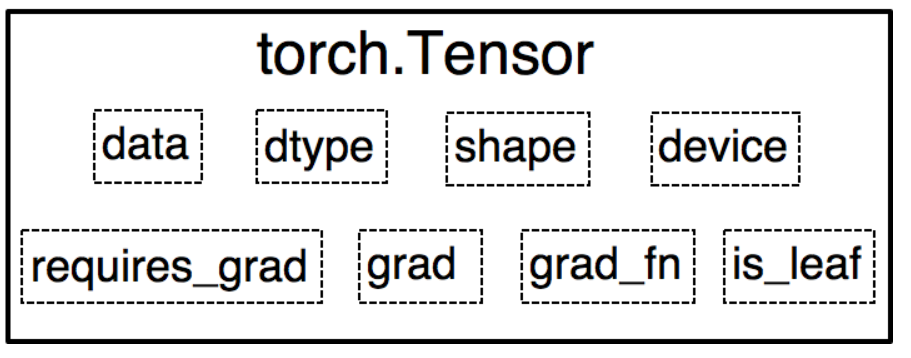  
在PyTorch的早期版本中，使用了tortor.autograd.Variable类来创建支持梯度计算和操作跟踪的张量，但自PyTorch v0.4.0起，不推荐使用Variable类。 torch.Tensor和torch.autograd.Variable现在是同一类。更准确地说，torch.Tensor能够跟踪历史记录，其行为类似于旧的Variable

#### 3）requires_grad
- 表示autograd时是否需要计算此tensor的梯度，默认False；
- requires_grad允许从梯度计算中细粒度地排除子图，并可以提高计算效率。
- **某个操作/tensor构成的模型中，只要有单个输入需要记录梯度(requires_grad=True)，则该操作/模型的输出也必然需要记录梯度(否则梯度是无法传递到该tensor上的)**。
- 当且仅当某个操作/模型上所有的输入都无需记录梯度时，输出才可以不记录梯度，设置为requires_grad=False。

**注意：requires_grad=True时张量类型必须为小数**

In [1]:
import torch

x = torch.randn(5, 5)  # requires_grad=False by default
y = torch.randn(5, 5) 
z = torch.randn((5, 5), requires_grad = True)
a = x + y
a.requires_grad

False

In [2]:
b = a * z
b.requires_grad

True

**实际应用中，requires_grad的用途：**

- 用于迁移学习
- 用预训练的(如ImageNet上)过的基础网络(如VGG/ResNet)做backbone，用作特征提取；基础网络后面接多层卷积网络/全连接层用于特征分类和box回归；训练时冻结backbone骨干网络的权重，不对其进行反向传播，于是我们需要将backbone网络的所有层和参数设置requires_grad = False。

In [3]:
def frozen_basenet(base_net):
    for param in base_net.parameters():
        param.requires_grad = False

#### 4）is_leaf
- 在反向传播过程中，只有 is_leaf=True 的时候，需要求导的张量的导数结果才会被最后保留下来。
- 对于任意一个张量来说，我们可以用 tensor.is_leaf 来判断它是否是叶子张量（leaf tensor）。
- 对于 requires_grad=False 的 tensor 来说，我们约定俗成地把它们归为叶子张量。
- 我们真正需要注意的是当 requires_grad=True 的时候，如何判断是否是叶子张量：当这个 tensor 是用户创建的时候，它是一个叶子节点，当这个 tensor 是由其他运算操作产生的时候，它就不是一个叶子节点。
- 对于叶子节点来说，它们的 grad_fn 属性都为空；而对于非叶子结点来说，因为它们是通过一些操作生成的，所以它们的 grad_fn 不为空。

In [5]:
a = torch.ones([2, 2], requires_grad = True)
print(a.is_leaf)

b = a + 2
print(b.is_leaf) # b不是用户创建，是计算生成的，所以是False

True
False


In [6]:
x = torch.tensor(2.0, requires_grad = True)
y = torch.tensor(3.0, requires_grad = True)
z = 2*x + y
x.grad_fn, y.grad_fn, z.grad_fn

(None, None, <AddBackward0 at 0x246dc11d7b0>)

#### 5） torch.autograd.Function

每一个原始的自动求导运算实际上是两个在Tensor上运行的函数(Autograd的核心)

- forward函数计算从输入Tensors获得的输出Tensors：前向传播
- backward函数接收输出Tensors对于某个标量值的梯度，并且计算输入Tensors相对于该相同标量值的梯度：反向传播
- 最后，利用apply方法执行相应的运算
    - 定义在Function类的父类 _FunctionBase中定义的一个方法

In [7]:
class line(torch.autograd.Function):
    @staticmethod
    def forward(ctx, w, x, b):
        # y = w*x + b
        ctx.save_for_backward(w, x, b) # 保存前向传播计算得到的值，将来反向传播需要使用
        return w * x + b

    def backward(ctx, grad_out): # grad_out就是之后的计算反向传播给line(也就是y)的导数
        w, x, b = ctx.saved_tensors

        grad_w = grad_out * x
        grad_x = grad_out * w
        grad_b = grad_out

        return grad_w, grad_x, grad_b
    
w = torch.rand(2, 2, requires_grad=True)
x = torch.rand(2, 2, requires_grad=True)
b = torch.rand(2, 2, requires_grad=True)

out = line.apply(w, x, b)
out.backward(torch.ones(2, 2))

print(w, x, b)
print(w.grad, x.grad, b.grad)

tensor([[0.6439, 0.0015],
        [0.4289, 0.3377]], requires_grad=True) tensor([[0.1209, 0.5539],
        [0.5085, 0.6449]], requires_grad=True) tensor([[0.2025, 0.9077],
        [0.8368, 0.0235]], requires_grad=True)
tensor([[0.1209, 0.5539],
        [0.5085, 0.6449]]) tensor([[0.6439, 0.0015],
        [0.4289, 0.3377]]) tensor([[1., 1.],
        [1., 1.]])


In [11]:
x = torch.tensor(2.0, requires_grad = True)
y = torch.tensor(3.0, requires_grad = True)
z = 2*x + y
z.backward(retain_graph = True)
# Displaying
for i, name in zip([x, y, z], "xyz"):
    print(f"{name}\n data: {i.data}\n requires_grad: {i.requires_grad}\n grad: {i.grad}\n grad_fn: {i.grad_fn}\n is_leaf: {i.is_leaf}\n")

x
 data: 2.0
 requires_grad: True
 grad: 2.0
 grad_fn: None
 is_leaf: True

y
 data: 3.0
 requires_grad: True
 grad: 1.0
 grad_fn: None
 is_leaf: True

z
 data: 7.0
 requires_grad: True
 grad: None
 grad_fn: <AddBackward0 object at 0x00000246E54557E0>
 is_leaf: False



C:\Users\lenovo\AppData\Local\Temp\ipykernel_16016\3669731200.py:7: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:497.)
  print(f"{name}\n data: {i.data}\n requires_grad: {i.requires_grad}\n grad: {i.grad}\n grad_fn: {i.grad_fn}\n is_leaf: {i.is_leaf}\n")


**注意：重复调用backward会导致导数在叶节点处累积。**

In [12]:
# Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.
# 也就是说要在第一次调用时指定
z.backward() 
# Displaying
for i, name in zip([x, y, z], "xyz"):
    print(f"{name}\n data: {i.data}\n requires_grad: {i.requires_grad}\n grad: {i.grad}\n grad_fn: {i.grad_fn}\n is_leaf: {i.is_leaf}\n")

x
 data: 2.0
 requires_grad: True
 grad: 4.0
 grad_fn: None
 is_leaf: True

y
 data: 3.0
 requires_grad: True
 grad: 2.0
 grad_fn: None
 is_leaf: True

z
 data: 7.0
 requires_grad: True
 grad: None
 grad_fn: <AddBackward0 object at 0x00000246E54572B0>
 is_leaf: False



C:\Users\lenovo\AppData\Local\Temp\ipykernel_16016\2472015523.py:6: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:497.)
  print(f"{name}\n data: {i.data}\n requires_grad: {i.requires_grad}\n grad: {i.grad}\n grad_fn: {i.grad_fn}\n is_leaf: {i.is_leaf}\n")


### 4.2 线性回归实现

定义训练数据的x和y：

In [13]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0] #t_c是摄氏度数
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4] #t_u是未知单位度数
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

定义模型和损失函数：

In [15]:
def model(t_u, w, b):
    return w*t_u + b

def loss_fn(t_p, t_c): # 均方差损失函数
    squared_diffs = (t_p - t_c) ** 2
    return squared_diffs.mean()

初始化参数张量：

In [16]:
params = torch.tensor([1.0, 0.0], requires_grad = True)#w和b 注意requires_grad=True和float类型

调用模型，计算损失值，然后对损失张量loss调用backward：

- 用一张图来形象地表示这个过程：
  
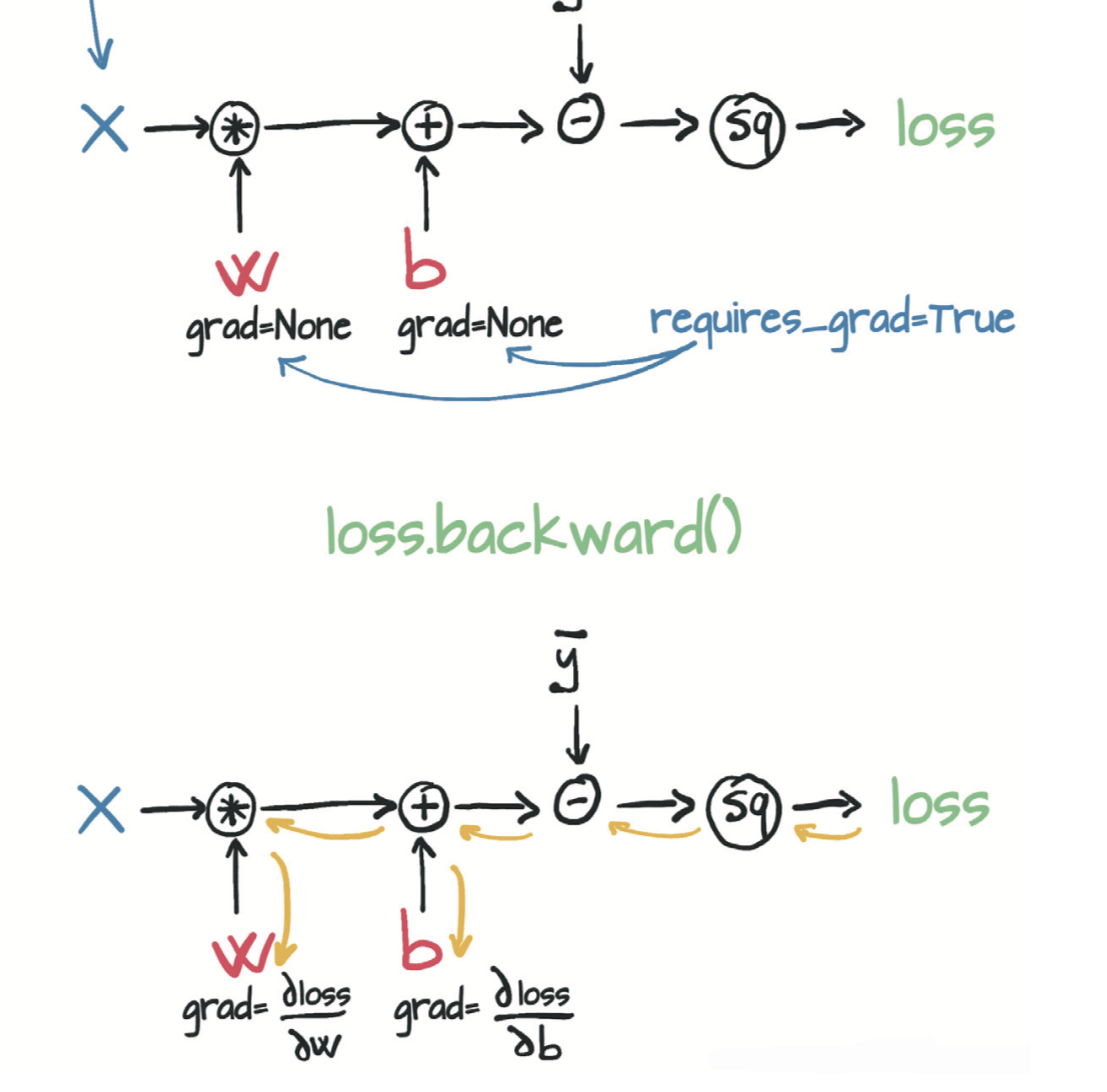

In [17]:
loss = loss_fn(model(t_u, *params), t_c)
loss.backward()
params.grad

tensor([4517.2969,   82.6000])

使用梯度下降并自动求导的完整代码：

- detach()：将新的params张量从与其更新表达式关联的计算图中分离出来。这样，params就会丢失关于生成它的相关运算的记忆。
- requires_grad_()，这是一个就地（in place）操作（注意下标“_”），以重新启用张量的自动求导

In [18]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        if params.grad is not None:
            #为防止梯度累积，你需要在每次迭代时将梯度显式清零。
            params.grad.zero_() #这可以在调用backward之前在循环中的任何时候完成
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)
        loss.backward() #方向传播求导
        params = (params - learning_rate * params.grad).detach().requires_grad_() #梯度下降更新参数，先从计算图中剥离出来再求导
        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
    
    return params

training_loop(
    n_epochs = 5000,
    learning_rate = 0.0002,
    params = params,
    t_u = t_u,
    t_c = t_c
)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16016\917822009.py:11: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  print('Epoch %d, Loss %f' % (epoch, float(loss)))


Epoch 500, Loss 28.213867
Epoch 1000, Loss 27.343616
Epoch 1500, Loss 26.503315
Epoch 2000, Loss 25.691925
Epoch 2500, Loss 24.908478
Epoch 3000, Loss 24.151983
Epoch 3500, Loss 23.421532
Epoch 4000, Loss 22.716209
Epoch 4500, Loss 22.035164
Epoch 5000, Loss 21.377560


tensor([ 0.2811, -2.7911], requires_grad=True)

### 4.3 认识优化器
#### 1）优化器工作原理

每个优化器构造函数都将参数（通常是将require_grad设置为True的PyTorch张量）作为第一个输入。传递给优化器的所有参数都保留在优化器对象内，以便优化器可以更新其值并访问其grad属性，如图所示：

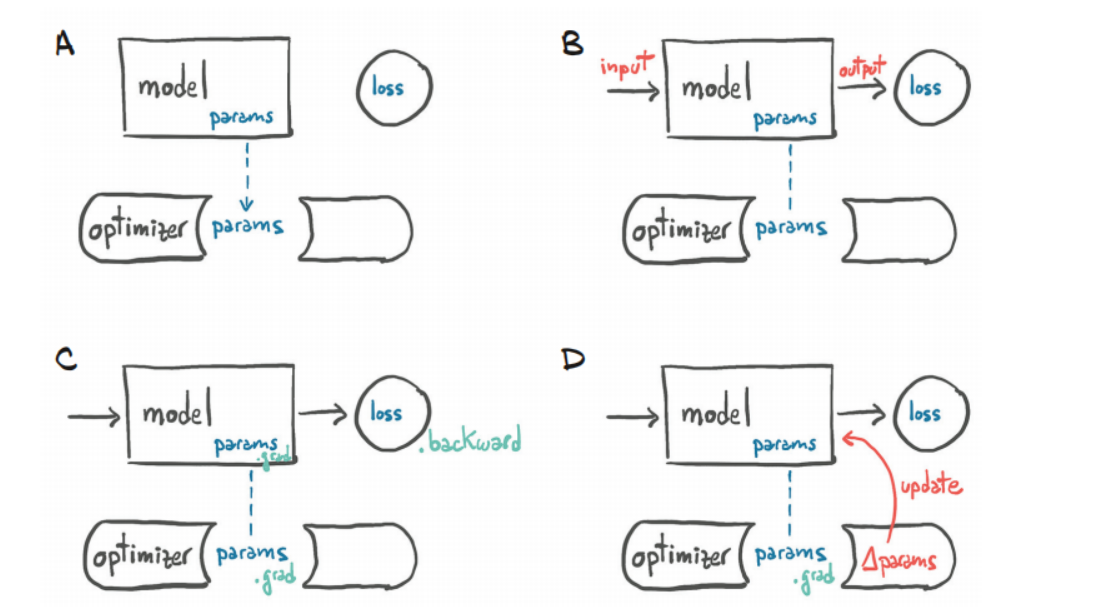

（A）优化器对参数的引用的概念表示，然后（B）根据输入计算损失，（C）对backward的调用会将grad填充到参数内。此时，（D）优化器可以访问grad并计算参数更新。

**每个优化器都有两个方法：**

- zero_grad：将构造时传递给优化器的所有参数的grad属性归零
- step：根据特定优化器实施的优化策略更新这些参数的值。

**修改training_loop函数为迭代器版本：**

In [19]:
def training_loop(n_epochs, optimizer, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)
        optimizer.zero_grad() # 清零梯度
        loss.backward()
        optimizer.step() # 更新参数
        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
    return params

In [20]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0] #摄氏度数
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4] #未知单位读数
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)
# require_grad = True这个参数告诉PyTorch需要追踪在params上进行运算而产生的所有张量
# 创建参数并实例化一个梯度下降优化器
params = torch.tensor([1.0, 0.0], requires_grad = True)
learning_rate = 1e-2
optimizer = torch.optim.SGD([params], lr = learning_rate)
t_un = 0.1 * t_u # 标准化操作的粗略替代
training_loop(
    n_epochs = 5000,
    optimizer = optimizer,
    params = params,
    t_u = t_un,
    t_c = t_c)

Epoch 500, Loss 7.860115
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957698
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927679
Epoch 4500, Loss 2.927652
Epoch 5000, Loss 2.927647


tensor([  5.3671, -17.3012], requires_grad=True)

#### 2）Variable与Parameter

我们知道网络中存在很多参数，这些参数需要在网络训练的过程中实时更新（一个batch更新一次），完成“学习”的过程

网络中若是有100个参数，都要手写更新代码吗？1000个呢？10000个呢...... Variable默认是不需要求梯度的，那还需要手动设置参数 requires_grad=True Variable因为要多次反向传播，那么在bcakward的时候还要手动注明参数w.backward(retain_graph=True) Pytorch主要通过引入nn.Parameter类型的变量和optimizer机制来解决了这个问题。 Parameter是Variable的子类，本质上和后者一样，只不过parameter默认是求梯度的 一个网络net中的parameter变量是可以通过 net.parameters()来很方便地访问到的，只需将网络中所有需要训练更新的参数定义为Parameter类型

In [ ]:
class Net(Module):
        def __init__(self, a, b, ...):
                super(net, self).__init__()
                self...   #  parameters
                self...    # layers
        def forward(self):
                x = ...
                x = ...    # 数据流
                return x
net = Net(a, b, ...)
net.train()
...
optimizer = torch.optim.SGD(net.parameters(), lr=1e-1)
# 然后在每一个batch中，调用optimizer.step()即可完成参数更新了（loss.backward()之后）